# Animal Classification Dataset - Exploratory Data Analysis

This notebook provides comprehensive analysis of the animal classification dataset and validates components for the NER + Image Classification pipeline.

In [1]:
# Import Required Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Setup plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Random seeds for reproducibility
np.random.seed(42)

## 1. Load and Explore Animal Dataset

This section loads the animal classification dataset and displays basic information.

In [ ]:
# Define dataset path and explore structure
DATASET_PATH = "./animals"  # Modify to your dataset path

# Discover classes automatically from the Animals-10 dataset folder structure
ANIMAL_CLASSES = sorted([
    d.name for d in Path(DATASET_PATH).iterdir()
    if d.is_dir() and not d.name.startswith(".")
])

# Fallback to known animals if folder scanning fails
if not ANIMAL_CLASSES:
    ANIMAL_CLASSES = [
        "cat", "dog", "horse", "elephant",
        "butterfly", "chicken", "cow", "sheep",
        "spider", "squirrel"
    ]

# Function to explore dataset
def explore_dataset(path):
    """Explore dataset structure and statistics"""
    if os.path.exists(path):
        total_images = 0
        class_counts = {}
        for class_name in ANIMAL_CLASSES:
            class_path = os.path.join(path, class_name)
            if os.path.exists(class_path):
                count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
                class_counts[class_name] = count
                total_images += count
        
        print(f"Dataset Path: {path}")
        print(f"Total Images: {total_images}")
        print(f"Number of Classes: {len(class_counts)}")
        print("\nClass Distribution:")
        for cls, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
            print(f"  {cls}: {count} images")
        return class_counts
    else:
        print(f"Dataset not found at {path}")
        print(f"Expected structure: {path}/[class_name]/[image files]")
        return {}

class_counts = explore_dataset(DATASET_PATH)

Dataset Path: ./animals
Total Images: 26179
Number of Classes: 10

Class Distribution:
  dog: 4863 images
  spider: 4821 images
  chicken: 3098 images
  horse: 2623 images
  butterfly: 2112 images
  cow: 1866 images
  squirrel: 1862 images
  sheep: 1820 images
  cat: 1668 images
  elephant: 1446 images


## 2. Analyze Dataset Distribution and Classes

Statistical analysis of class distribution and data balance.

In [4]:
# Calculate distribution statistics
if class_counts:
    df_dist = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
    df_dist['Percentage'] = (df_dist['Count'] / df_dist['Count'].sum() * 100).round(2)
    df_dist = df_dist.sort_values('Count', ascending=False)
    
    print("Dataset Statistics:")
    print(f"Total Samples: {df_dist['Count'].sum()}")
    print(f"Average per Class: {df_dist['Count'].mean():.1f}")
    print(f"Std Dev: {df_dist['Count'].std():.1f}")
    print(f"Min Class Size: {df_dist['Count'].min()}")
    print(f"Max Class Size: {df_dist['Count'].max()}")
    print(f"\nClass Balance Ratio: {df_dist['Count'].max() / df_dist['Count'].min():.2f}x")
    print("\n", df_dist.to_string(index=False))
else:
    print("No dataset found. Please prepare the dataset first.")

Dataset Statistics:
Total Samples: 26179
Average per Class: 2617.9
Std Dev: 1266.2
Min Class Size: 1446
Max Class Size: 4863

Class Balance Ratio: 3.36x

     Class  Count  Percentage
      dog   4863       18.58
   spider   4821       18.42
  chicken   3098       11.83
    horse   2623       10.02
butterfly   2112        8.07
      cow   1866        7.13
 squirrel   1862        7.11
    sheep   1820        6.95
      cat   1668        6.37
 elephant   1446        5.52


## 3. Visualize Sample Images and Statistics

Display sample images from each class and create distribution charts.

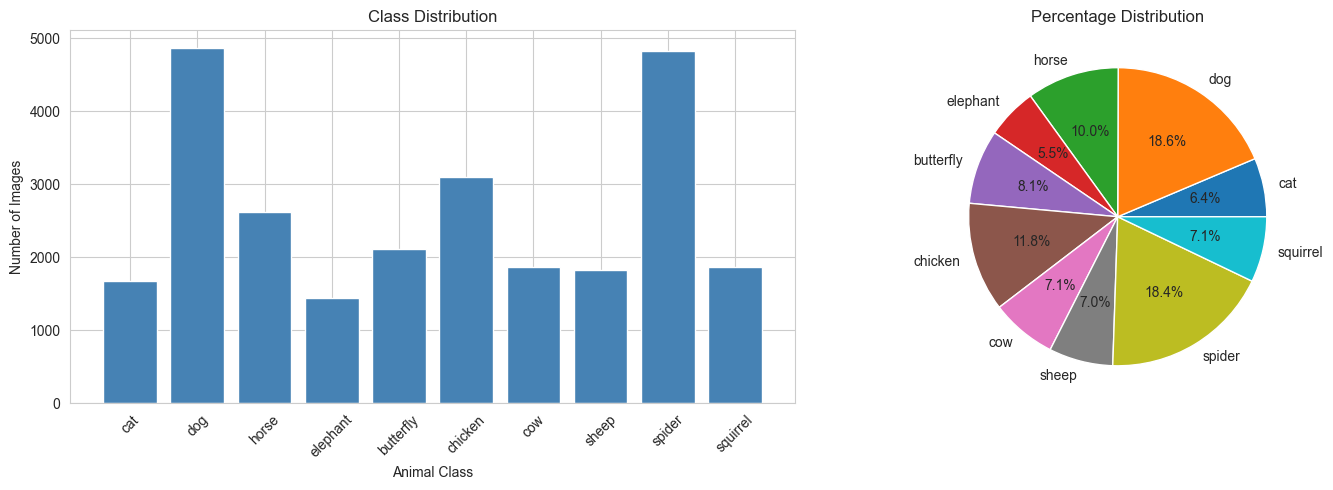

Sample images from the dataset:


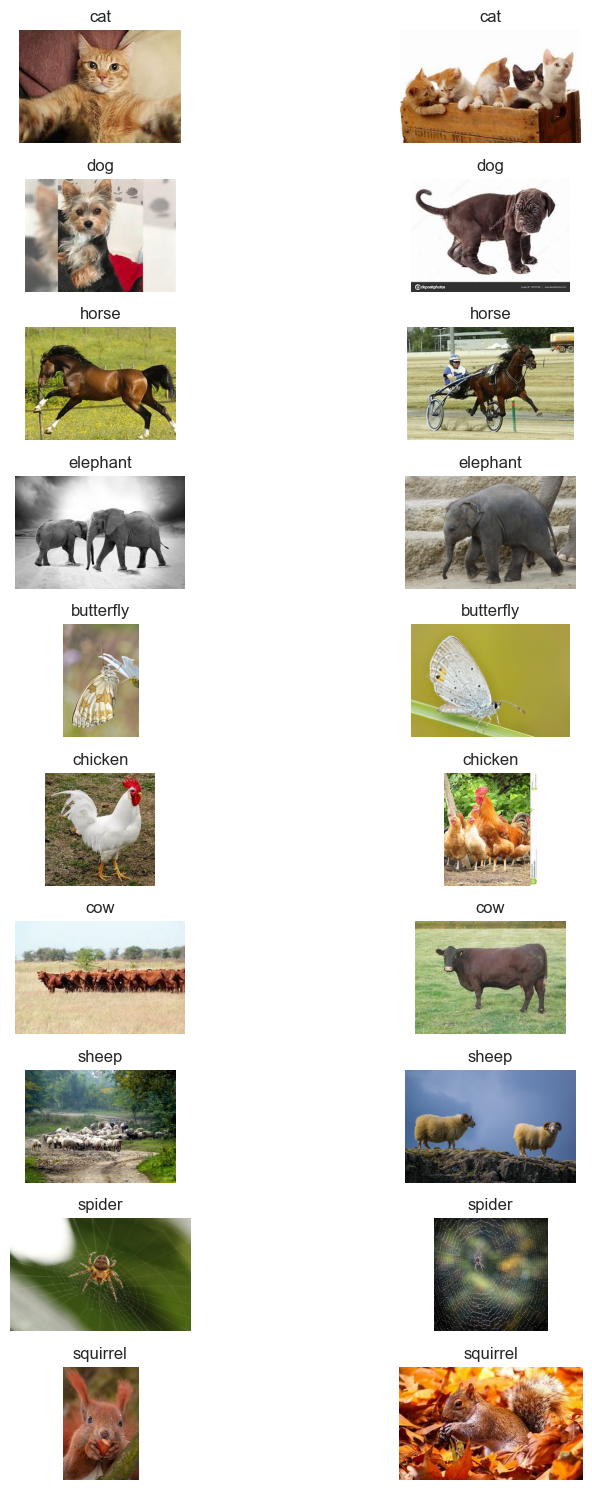

In [5]:
# Visualize class distribution
if class_counts:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Bar chart
    classes = list(class_counts.keys())
    counts = list(class_counts.values())
    axes[0].bar(classes, counts, color='steelblue')
    axes[0].set_xlabel('Animal Class')
    axes[0].set_ylabel('Number of Images')
    axes[0].set_title('Class Distribution')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Pie chart
    axes[1].pie(counts, labels=classes, autopct='%1.1f%%')
    axes[1].set_title('Percentage Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # Sample image display function
    def display_sample_images(dataset_path, classes, samples_per_class=2):
        """Display sample images from each class"""
        if not os.path.exists(dataset_path):
            print(f"Dataset path not found: {dataset_path}")
            return
        
        fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(10, 15))
        axes = axes.flatten() if len(classes) > 1 else [axes]
        
        idx = 0
        for cls in classes[:len(axes)//samples_per_class]:
            cls_path = os.path.join(dataset_path, cls)
            if os.path.exists(cls_path):
                images = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
                for img_file in images[:samples_per_class]:
                    img_path = os.path.join(cls_path, img_file)
                    try:
                        img = Image.open(img_path)
                        axes[idx].imshow(img)
                        axes[idx].set_title(f"{cls}")
                        axes[idx].axis('off')
                        idx += 1
                    except:
                        pass
        
        plt.tight_layout()
        plt.show()
    
    # Display samples if dataset exists
    if os.path.exists(DATASET_PATH):
        print("Sample images from the dataset:")
        display_sample_images(DATASET_PATH, list(class_counts.keys()))

## 4. Prepare Data for NER Model

Create synthetic training data with animal entity annotations using IOB tagging format.

In [ ]:
# Generate synthetic NER training data
def generate_synthetic_ner_data(animals, num_samples=100):
    """Generate synthetic text with animal entity annotations"""
    templates = [
        "There is a {} in the picture.",
        "I can see a {} here.",
        "This image shows a {}.",
        "I spotted a {} in the photo.",
        "The {} is visible in this image.",
        "I found a {} in the picture.",
        "This is a picture of a {}.",
        "There is a beautiful {} here.",
        "A {} can be seen in the image.",
        "I see a {} in this photo.",
    ]
    
    ner_texts = []
    for _ in range(num_samples):
        template = templates[np.random.randint(0, len(templates))]
        animal = animals[np.random.randint(0, len(animals))]
        text = template.format(animal)
        ner_texts.append(text)
    
    return ner_texts

# Generate synthetic NER data
synthetic_ner_data = generate_synthetic_ner_data(ANIMAL_CLASSES, num_samples=50)
print("Sample synthetic NER training texts:")
for text in synthetic_ner_data[:5]:
    print(f"  - {text}")
print(f"\nTotal synthetic NER samples: {len(synthetic_ner_data)}")

## 5. Prepare Data for Image Classification Model

Split dataset into train/validation/test sets with augmentation strategy.

In [6]:
# Data splitting strategy
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

def calculate_split_sizes(class_counts, train_split=0.7, val_split=0.15):
    """Calculate split sizes for each class"""
    split_info = []
    for cls, count in class_counts.items():
        train_size = int(count * train_split)
        val_size = int(count * val_split)
        test_size = count - train_size - val_size
        split_info.append({
            'Class': cls,
            'Total': count,
            'Train': train_size,
            'Val': val_size,
            'Test': test_size
        })
    return pd.DataFrame(split_info)

if class_counts:
    split_df = calculate_split_sizes(class_counts)
    print("Proposed Data Split (Train/Val/Test):")
    print(split_df.to_string(index=False))
    print(f"\nTotal Train: {split_df['Train'].sum()}")
    print(f"Total Val: {split_df['Val'].sum()}")
    print(f"Total Test: {split_df['Test'].sum()}")
    
    # Data augmentation info
    print("\n" + "="*50)
    print("Data Augmentation Strategy:")
    print("="*50)
    print("- Random rotation: ±20 degrees")
    print("- Random horizontal flip: 50% probability")
    print("- Color jitter: brightness, contrast variation")
    print("- Normalization: ImageNet mean/std")
    print("- Resize: 224x224 (for transfer learning models)")

Proposed Data Split (Train/Val/Test):
    Class  Total  Train  Val  Test
      cat   1668   1167  250   251
      dog   4863   3404  729   730
    horse   2623   1836  393   394
 elephant   1446   1012  216   218
butterfly   2112   1478  316   318
  chicken   3098   2168  464   466
      cow   1866   1306  279   281
    sheep   1820   1274  273   273
   spider   4821   3374  723   724
 squirrel   1862   1303  279   280

Total Train: 18322
Total Val: 3922
Total Test: 3935

Data Augmentation Strategy:
- Random rotation: ±20 degrees
- Random horizontal flip: 50% probability
- Color jitter: brightness, contrast variation
- Normalization: ImageNet mean/std
- Resize: 224x224 (for transfer learning models)


## 6. Pipeline Integration Testing

Test the complete pipeline architecture with sample inputs.

In [ ]:
# Pipeline flow demonstration
print("="*60)
print("PIPELINE ARCHITECTURE")
print("="*60)
print("\n1. INPUT STAGE:")
print("   - Text: 'There is a dog in the picture'")
print("   - Image: [224x224 RGB array]")

print("\n2. NER STAGE:")
print("   - Model: Transformer-based NER (e.g., BERT)")
print("   - Task: Extract animal entity from text")
print("   - Output: ['dog']")

print("\n3. IMAGE CLASSIFICATION STAGE:")
print("   - Model: ResNet/ViT with transfer learning")
print("   - Task: Classify animal in image")
print("   - Output: 'dog' (top-1 prediction)")

print("\n4. COMPARISON STAGE:")
print("   - Match NER entities with classification output")
print("   - Verify confidence thresholds")

print("\n5. OUTPUT:")
print("   - Boolean: True/False (match or no match)")

print("\n" + "="*60)
print("EXPECTED PIPELINE BEHAVIOR:")
print("="*60)
print("✓ Text: 'There is a dog'  +  Image: [dog picture]   → True")
print("✓ Text: 'There is a cat'  +  Image: [dog picture]   → False")
print("✓ Text: 'Animal in image' +  Image: [dog picture]   → False (no entity)")
print("✓ Text: 'There is a DOG'  +  Image: [dog picture]   → True (case insensitive)")

PIPELINE ARCHITECTURE

1. INPUT STAGE:
   - Text: 'There is a dog in the picture'
   - Image: [224x224 RGB array]

2. NER STAGE:
   - Model: Transformer-based NER (e.g., BERT)
   - Task: Extract animal entity from text
   - Output: ['dog']

3. IMAGE CLASSIFICATION STAGE:
   - Model: ResNet/ViT with transfer learning
   - Task: Classify animal in image
   - Output: 'dog' (top-1 prediction)

4. COMPARISON STAGE:
   - Match NER entities with classification output
   - Verify confidence thresholds

5. OUTPUT:
   - Boolean: True/False (match or no match)

EXPECTED PIPELINE BEHAVIOR:
✓ Text: 'There is a dog'  +  Image: [dog picture]   → True
✓ Text: 'There is a cat'  +  Image: [dog picture]   → False
✓ Text: 'Animal in image' +  Image: [dog picture]   → False (no entity)
✓ Text: 'There is a DOG'  +  Image: [dog picture]   → True (case insensitive)


: 